In [72]:
import numpy as np
import itertools
import time
from collections import defaultdict

In [73]:
GRID = [['S','F','F','D','F','R'],
        ['F','X','F','W','F','F'],
        ['F','F','R','F','D','F'],
        ['C','F','X','F','F','W'],
        ['F','D','F','F','R','F'],
        ['C','F','F','D','X','F'] ]

In [74]:
ACTIONS = { 0: (-1,0), # UP
            1: (1,0), # DOWN
            2: (0,-1), # LEFT
            3: (0,1), # RIGHT
            4: (0,0) # HOVER
          }

In [75]:
ACTION_NAMES = { 0:"↑", 1:"↓", 2:"←", 3:"→", 4:"H" }

In [76]:
class DroneRescueEnv:
  def __init__(self):
    self.grid = GRID
    self.rows = 6
    self.cols = 6
    self.max_battery = 15
    self.wind_prob = 0.30
    self.step_limit = 75
    self.start_pos = (0,0)
    self.rescue_positions = [ (0,5), (2,2), (4,4) ]
    self.reset()

  def reset(self):
    self.position = self.start_pos
    self.battery = self.max_battery
    self.steps = 0
    self.rescued = [0,0,0]
    return self.get_state()

  def get_state(self):
    return ( self.position[0], self.position[1], self.battery, tuple(self.rescued) )

  def move(self,row,col,action):
    dr,dc = ACTIONS[action]
    nr = row + dr
    nc = col + dc
    if nr < 0 or nr >= self.rows:
      return row,col
    if nc < 0 or nc >= self.cols:
      return row,col
    if self.grid[nr][nc] == 'X':
      return row,col
    return nr,nc

def render(self):
   for row in self.grid:
    print(" ".join(row))

def generate_states(env):
  states = []
  for r in range(env.rows):
    for c in range(env.cols):
      if env.grid[r][c] == 'X':
        continue
      for battery in range(env.max_battery + 1):
        for rescued in itertools.product( [0,1], repeat=3):
          states.append( (r,c,battery,rescued) )
  return states





In [79]:
def simulate_transition(env,state,action):
  row,col,battery,rescued = state
  rescued = list(rescued)
  battery -= 1
  reward = -1
  nr,nc = env.move( row,col,action )
  cell = env.grid[nr][nc]
  # hover charging
  if action == 4 and cell == 'C':
   battery = min( env.max_battery, battery + 2 )
  # charging station
  if cell == 'C':
    battery = env.max_battery
    reward += 5
  # danger
  if cell == 'D':
    reward -= 10
  # rescue
  for idx,pos in enumerate( env.rescue_positions ):
    if (nr,nc) == pos:
      if rescued[idx] == 0:
        rescued[idx] = 1
        reward += 20
  # battery exhausted
  if battery <= 0:
    battery = 0
    reward -= 20
  next_state = ( nr, nc, battery, tuple(rescued) )
  return next_state,reward

In [80]:
def get_transitions(env,state,action):
  row,col,battery,rescued = state
  if battery == 0:
    return [(1.0,state,0)]
  if all(rescued):
    return [(1.0,state,0)]
  current_cell = env.grid[row][col]
  transitions = []
  if current_cell != 'W' or action == 4:
    ns,r = simulate_transition( env,state,action )
    return [(1.0,ns,r)]
  intended_prob = 1 - env.wind_prob
  random_prob = env.wind_prob / 4
  ns,r = simulate_transition( env,state,action )
  transitions.append( (intended_prob,ns,r) )
  for random_action in [0,1,2,3]:
    ns,r = simulate_transition( env,state, random_action )
    transitions.append( (random_prob,ns,r) )
  merged = defaultdict(float)
  rewards = {}
  for p,s,r in transitions:
    merged[s] += p
    rewards[s] = r
  result = []
  for s,p in merged.items():
    result.append( (p,s,rewards[s]) )
  return result

In [81]:
def value_iteration( env, states, gamma=0.95, theta=1e-3):
  V = { s:0.0 for s in states }
  iteration = 0
  start = time.time()
  while True:
    iteration += 1
    delta = 0
    for state in states:
      old_v = V[state]
      action_values = []

      for action in range(5):
        q = 0
        transitions = get_transitions( env, state, action )

        for prob,next_state,reward in transitions:
          q += prob * ( reward + gamma * V[next_state] )
        action_values.append(q)
      V[state] = max(action_values)
      delta = max( delta, abs(old_v - V[state]) )
    if delta < theta: break
  runtime = time.time() - start
  policy = {}
  for state in states:
    best_action = None
    best_value = float("-inf")
    for action in range(5):
      q = 0
      transitions = get_transitions( env, state, action )
      for prob,next_state,reward in transitions:
        q += prob * ( reward + gamma * V[next_state] )
        if q > best_value:
          best_value = q
          best_action = action
    policy[state] = best_action
  return V,policy,iteration,delta,runtime

In [82]:
def show_policy(env,policy):
  battery = env.max_battery
  rescued = (0,0,0)
  print("\nPolicy Grid\n")
  for r in range(env.rows):
    row_display = []
    for c in range(env.cols):
      cell = env.grid[r][c]
      if cell in ['X','D','R','C','W']:
        row_display.append(cell)
        continue
      state = ( r,c, battery, rescued )
      action = policy[state]
      row_display.append( ACTION_NAMES[action] )
      print(" ".join(row_display))

In [83]:
# VALUE HEATMAP DATA

In [84]:
def value_grid(env,V):
  battery = env.max_battery
  rescued = (0,0,0)
  values = np.zeros( (env.rows,env.cols) )
  for r in range(env.rows):
    for c in range(env.cols):
      if env.grid[r][c] == 'X':
        values[r,c] = np.nan
      else:
        state = ( r,c, battery, rescued )
        values[r,c] = V[state]
  return values

In [85]:
env = DroneRescueEnv()
states = generate_states(env)
print("Total States:", len(states))
V,policy,iters,delta,runtime = value_iteration( env, states )
print("\nConvergence Results")
print("-------------------")
print("Iterations:", iters)
print("Final Delta:", delta)
print("Runtime:", runtime)
show_policy(env,policy)
heatmap_values = value_grid(env,V)
print("\nValue Function Slice")
print(heatmap_values)

Total States: 4224

Convergence Results
-------------------
Iterations: 163
Final Delta: 0.0009846549037888508
Runtime: 7.086738109588623

Policy Grid

↓
↓ →
↓ → ↓
↓ → ↓ D →
↓
↓ X ↓
↓ X ↓ W →
↓ X ↓ W → ↑
→
→ →
→ → R ←
→ → R ← D ↑
C ↑
C ↑ X ↓
C ↑ X ↓ ↓
↑
↑ D →
↑ D → →
↑ D → → R ←
C ←
C ← ↑
C ← ↑ D X ↑

Value Function Slice
[[70.63980469 75.41120938 80.43374063 75.4120536  79.86255692 79.86327489]
 [75.41120938         nan 85.72061563 78.1749832  74.84250409 79.86327489]
 [80.43374063 85.72061563 85.72145985 85.72145985 80.80390945 74.84318619]
 [79.98355394 80.43458485         nan 80.80390945 86.11010218 79.53121617]
 [79.98437625 75.76302636 80.80390945 86.11010218 86.11078981 86.11078981]
 [79.98354998 79.98437248 75.76371398 80.80459708         nan 80.80525032]]


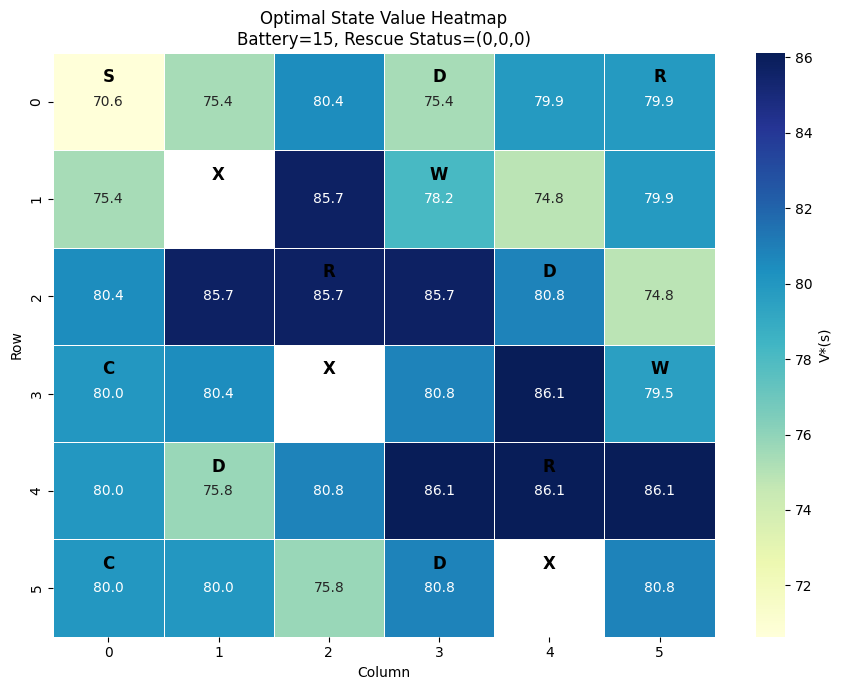

In [86]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

heatmap_values = value_grid(env, V)

plt.figure(figsize=(9,7))

ax = sns.heatmap(
    heatmap_values,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    linewidths=0.5,
    cbar_kws={"label": "V*(s)"}
)

for r in range(env.rows):
    for c in range(env.cols):

        cell = env.grid[r][c]

        if cell != 'F':

            ax.text(
                c + 0.5,
                r + 0.25,
                cell,
                ha='center',
                va='center',
                fontsize=12,
                fontweight='bold'
            )

plt.title(
    "Optimal State Value Heatmap\n"
    "Battery=15, Rescue Status=(0,0,0)"
)

plt.xlabel("Column")
plt.ylabel("Row")

plt.tight_layout()

plt.show()

# **DP Scalability Discussion**

**Curse of Dimensionality**

Dynamic Programming (DP) methods such as Value Iteration require evaluating every possible state in the MDP. As more state variables are added, the number of states grows rapidly, leading to the Curse of Dimensionality.

In the current 6×6 drone rescue environment, a state consists of:

[
(row,; col,; battery,; rescue_status)
]

With 33 valid cells, 16 battery levels, and 3 rescue targets:

[
33 \times 16 \times 2^3 = 4224
]

possible states.

This state space is manageable for Value Iteration.

**Impact of Larger Environments**

If the grid size increases to 10×10, the number of position states grows significantly, increasing both memory usage and computation time.

Adding more rescue targets has an even larger impact because rescue status combinations grow exponentially. For example, increasing from 3 to 5 rescue targets changes the rescue configurations from:

[
2^3 = 8
]

to

[
2^5 = 32
]

which greatly increases the overall state space.

If dynamic weather conditions are introduced, additional weather-related variables must be included in the state representation, making the problem even larger.

**Limitations of Dynamic Programming**

DP requires:

Explicit enumeration of all states.
Knowledge of transition probabilities.
Repeated updates until convergence.

As the state space grows, DP becomes slower and more memory intensive, making it difficult to apply to large real-world problems.

**How Deep Reinforcement Learning Helps**

Deep Reinforcement Learning (DRL) methods such as DQN and PPO use neural networks to approximate value functions instead of storing values for every state. This allows them to handle much larger and more complex environments.

**Relation to Real-World Drone Systems**

Real rescue drones operate in dynamic environments with changing weather, uncertain sensor data, moving obstacles, and continuous state variables. In such scenarios, Dynamic Programming is not practical, while Deep Reinforcement Learning provides a more scalable solution.

# State Representation and Reward Design

## State Representation

The Drone Rescue problem was modelled as a Markov Decision Process (MDP). Each state contains all the information required for the drone to make an optimal decision.

A state is represented as:

[
s = (row,; col,; battery,; rescue_status)
]

where:

* **row, col** represent the current position of the drone in the 6×6 grid.
* **battery** represents the remaining battery level (0–15).
* **rescue_status** stores whether each rescue target has been rescued.

Since there are three rescue targets, the rescue status is represented as a tuple:

[
(r_1,r_2,r_3)
]

where each value is:

* 0 = target not rescued
* 1 = target rescued

For example:

[
(2,2,10,(1,0,1))
]

indicates that the drone is at position (2,2), has 10 battery units remaining, and has completed the first and third rescues while the second rescue is still pending.

This state representation allows the agent to consider its location, remaining energy, and mission progress when selecting actions.

## Reward Design

The reward function was designed to encourage successful rescues while promoting safe and efficient navigation.

| Event                  | Reward |
| ---------------------- | ------ |
| Rescue target reached  | +20    |
| Reach charging station | +5     |
| Regular movement       | -1     |
| Enter danger zone      | -10    |
| Battery exhausted      | -20    |

A large positive reward (+20) is given for rescuing civilians to make rescue completion the primary objective. Charging stations provide a smaller positive reward (+5) to encourage battery management. A movement penalty (-1) is applied to every action to motivate shorter and more efficient paths. Entering danger zones results in a significant penalty (-10), encouraging the drone to avoid hazardous areas whenever possible. Finally, battery depletion incurs a heavy penalty (-20) because mission failure should be strongly discouraged.

Overall, the reward structure balances rescue completion, battery management, and safe navigation, enabling the Value Iteration algorithm to learn an effective rescue policy.
